In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

print("1. Loading the 16-column Gold Standard Data...")
train = pd.read_parquet('/content/train_master.parquet')
test = pd.read_parquet('/content/test_master (1).parquet')

# --- TIME FEATURE ENGINEERING FUNCTION ---
def feature_engineering(df):
    data = df.copy()

    # Extract time-based features from Date
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek

    # Weekend indicator: Saturday (5) and Sunday (6) = 1, Weekdays = 0
    data['is_weekend'] = np.where(data['dayofweek'] >= 5, 1, 0)

    # Payday indicator: 15th of the month and the last day of the month
    data['is_payday'] = np.where((data['day'] == 15) | (data['date'].dt.is_month_end), 1, 0)

    # Drop 'id' and 'date' columns as the model cannot process them directly
    if 'id' in data.columns:
        data = data.drop(columns=['id'])
    data = data.drop(columns=['date'])

    return data

print("\n2. Extracting time features and creating Payday indicator...")
train_features = feature_engineering(train)
test_features = feature_engineering(test)

# --- DYNAMIC LABEL ENCODING ---
print("\n3. Scanning and encoding categorical variables (Label Encoding)...")
# Automatically detect all columns containing strings/objects
categorical_cols = train_features.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

# Exclude 'description' column if it exists
if 'description' in categorical_cols:
    categorical_cols.remove('description')

print(f" -> Detected categorical columns to encode: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()

    # Convert to string and fill missing values with 'Unknown'
    train_features[col] = train_features[col].fillna('Unknown').astype(str)
    test_features[col] = test_features[col].fillna('Unknown').astype(str)

    # Combine train and test data to fit the LabelEncoder on all possible categories
    combined_data = pd.concat([train_features[col], test_features[col]])
    le.fit(combined_data)

    # Transform text into numerical labels
    train_features[col] = le.transform(train_features[col])
    test_features[col] = le.transform(test_features[col])

print("\n4. Final cleanup (Handling 'description' and filling remaining NaNs with 0)...")

# Handle 'description' column specifically to ensure it remains string type and fill NaNs
if 'description' in train_features.columns:
    print(" -> Converting 'description' column to string and filling NaNs with empty string.")
    train_features['description'] = train_features['description'].astype(str).fillna('')
    test_features['description'] = test_features['description'].astype(str).fillna('')

# Ensure there are no missing values left for other columns
train_features = train_features.fillna(0)
test_features = test_features.fillna(0)

print("\n5. Exporting AI-Ready files (100% Numeric Matrix)...")
train_features.to_parquet('train_AI_ready1.parquet', index=False)
test_features.to_parquet('test_AI_ready1.parquet', index=False)

print("\n=> DONE! FEATURE ENGINEERING COMPLETED SUCCESSFULLY!")

1. Loading the 16-column Gold Standard Data...

2. Extracting time features and creating Payday indicator...

3. Scanning and encoding categorical variables (Label Encoding)...
 -> Detected categorical columns to encode: ['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name']

4. Final cleanup (Handling 'description' and filling remaining NaNs with 0)...
 -> Converting 'description' column to string and filling NaNs with empty string.

5. Exporting AI-Ready files (100% Numeric Matrix)...

=> DONE! FEATURE ENGINEERING COMPLETED SUCCESSFULLY!


In [3]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0


In [4]:
import pandas as pd

# Giả sử file tên là data.parquet
df = pd.read_parquet("/content/test_AI_ready1.parquet")
df.copy()
# Xem vài dòng đầu tiên
df.head()


,store_nbr,family,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transactions,year,month,day,dayofweek,is_weekend,is_payday
0,1,0,0,18,12,3,13,46.8,5,3,23,None,0.0,2017,8,16,2,0,0
1,1,1,0,18,12,3,13,46.8,5,3,23,None,0.0,2017,8,16,2,0,0
2,1,2,2,18,12,3,13,46.8,5,3,23,None,0.0,2017,8,16,2,0,0
3,1,3,20,18,12,3,13,46.8,5,3,23,None,0.0,2017,8,16,2,0,0
4,1,4,0,18,12,3,13,46.8,5,3,23,None,0.0,2017,8,16,2,0,0


In [5]:
d1 = pd.read_parquet("/content/train_AI_ready1.parquet")
d1.copy()
d1.head()

,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transactions,year,month,day,dayofweek,is_weekend,is_payday
0,1,0,0.0,0,18,12,3,13,93.14,3,1,4,Primer dia del ano,0.0,2013,1,1,1,0,0
1,1,1,0.0,0,18,12,3,13,93.14,3,1,4,Primer dia del ano,0.0,2013,1,1,1,0,0
2,1,2,0.0,0,18,12,3,13,93.14,3,1,4,Primer dia del ano,0.0,2013,1,1,1,0,0
3,1,3,0.0,0,18,12,3,13,93.14,3,1,4,Primer dia del ano,0.0,2013,1,1,1,0,0
4,1,4,0.0,0,18,12,3,13,93.14,3,1,4,Primer dia del ano,0.0,2013,1,1,1,0,0


In [6]:
d3 = pd.read_parquet("/content/train_master.parquet")
d3.copy()
d3.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador,Primer dia del ano,0.0


In [7]:
d4 = pd.read_parquet("/content/test_master (1).parquet")
d4.copy()
d4.head()

,id,date,store_nbr,family,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transactions
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,46.8,None,None,None,None,0.0
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,46.8,None,None,None,None,0.0
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,46.8,None,None,None,None,0.0
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,46.8,None,None,None,None,0.0
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,46.8,None,None,None,None,0.0


In [8]:
import numpy as np

# Xác định biến mục tiêu (y) và các biến đặc trưng (X) cho tập huấn luyện (d1)
y = d1['sales']
X = d1.drop('sales', axis=1)
df_train_clean = d1.copy() # Use .copy() to avoid SettingWithCopyWarning later
df_test_clean = df.copy() # Use .copy()

print(f"Hình dạng của X (features): {X.shape}")
print(f"Hình dạng của y (target): {y.shape}")

Hình dạng của X (features): (3000888, 19)
Hình dạng của y (target): (3000888,)


# **Tạo thêm các biến liên quan đến thời gian để cải thiện hiệu suất mô hình**

### Tối ưu hóa Bộ nhớ DataFrame (Early Stage)

Để tránh lỗi hết RAM, chúng ta sẽ tối ưu hóa việc sử dụng bộ nhớ của các DataFrame `df_train_clean` và `df_test_clean` ngay từ đầu. Hàm `reduce_mem_usage` sẽ chuyển đổi các cột số học sang kiểu dữ liệu nhỏ hơn và các cột đối tượng (`object`) sang kiểu `category`. Điều này giúp giảm đáng kể kích thước DataFrame.

In [9]:
import numpy as np
import gc

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Chuyển đổi cột object sang category để tiết kiệm bộ nhớ
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {(100 * (start_mem - end_mem) / start_mem):.1f}%')
    return df

In [10]:
def create_time_features(df):
    # Reconstruct date column
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

    df['dayofyear'] = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['dayofmonth'] = df['date'].dt.day
    df['quarter'] = df['date'].dt.quarter
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['is_year_start'] = df['date'].dt.is_year_start.astype(int)
    df['is_year_end'] = df['date'].dt.is_year_end.astype(int)

    # Drop the temporary 'date' column
    df = df.drop(columns=['date'])
    return df

# Áp dụng hàm cho cả df_train_clean và df_test_clean
df_train_clean = create_time_features(df_train_clean)
df_test_clean = create_time_features(df_test_clean)

print("Đã tạo các đặc trưng thời gian mới cho df_train_clean và df_test_clean.")

# Cập nhật danh sách các đặc trưng cho mô hình
# (Sẽ được sử dụng trong các bước huấn luyện và đánh giá mô hình tiếp theo)
current_features = ['store_nbr', 'family', 'onpromotion', 'month', 'dayofweek', 'is_weekend', 'dcoilwtico']
new_features = ['dayofyear', 'weekofyear', 'dayofmonth', 'quarter',
                'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end']


updated_features = current_features + new_features

print("Danh sách đặc trưng đã cập nhật:")
print(updated_features)

# Hiển thị vài dòng đầu tiên của DataFrame đã được cập nhật để xem các biến mới
display(df_train_clean.head())

Đã tạo các đặc trưng thời gian mới cho df_train_clean và df_test_clean.
Danh sách đặc trưng đã cập nhật:
['store_nbr', 'family', 'onpromotion', 'month', 'dayofweek', 'is_weekend', 'dcoilwtico', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end']


,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,...,is_weekend,is_payday,dayofyear,weekofyear,dayofmonth,quarter,is_month_start,is_month_end,is_year_start,is_year_end
0,1,0,0.0,0,18,12,3,13,93.14,3,...,0,0,1,1,1,1,1,0,1,0
1,1,1,0.0,0,18,12,3,13,93.14,3,...,0,0,1,1,1,1,1,0,1,0
2,1,2,0.0,0,18,12,3,13,93.14,3,...,0,0,1,1,1,1,1,0,1,0
3,1,3,0.0,0,18,12,3,13,93.14,3,...,0,0,1,1,1,1,1,0,1,0
4,1,4,0.0,0,18,12,3,13,93.14,3,...,0,0,1,1,1,1,1,0,1,0


In [11]:
# Xác định ngày xảy ra động đất
eq_date = pd.Timestamp('2016-04-16')
print(f"Ngày xảy ra động đất: {eq_date}")

def add_earthquake_features(df, eq_date):
    # Reconstruct date column for feature calculation if not already present
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

    # Tính số ngày kể từ trận động đất
    df['days_since_earthquake'] = (df['date'] - eq_date).dt.days

    # Tạo biến nhị phân cho giai đoạn phục hồi sau động đất (14 ngày sau sự kiện)
    df['is_earthquake_recovery'] = ((df['date'] >= eq_date) &
                                   (df['date'] <= eq_date + pd.Timedelta(days=14))).astype(int)

    # Drop the temporary 'date' column if it was created here and is not needed otherwise
    if 'date' in df.columns and 'year' in df.columns: # Check if 'date' was temporary (year, month, day are also present)
        df = df.drop(columns=['date'])

    return df

# Áp dụng hàm cho cả df_train_clean và df_test_clean
df_train_clean = add_earthquake_features(df_train_clean, eq_date)
df_test_clean = add_earthquake_features(df_test_clean, eq_date)

print("Đã tạo các đặc trưng liên quan đến động đất cho df_train_clean và df_test_clean.")
print(f"Số dòng trong giai đoạn phục hồi sau động đất (df_train_clean): {df_train_clean.is_earthquake_recovery.sum()}")
print(f"Số dòng trong giai đoạn phục hồi sau động đất (df_test_clean): {df_test_clean.is_earthquake_recovery.sum()}")

# Hiển thị vài dòng đầu tiên để xem các biến mới
display(df_train_clean.head())

Ngày xảy ra động đất: 2016-04-16 00:00:00
Đã tạo các đặc trưng liên quan đến động đất cho df_train_clean và df_test_clean.
Số dòng trong giai đoạn phục hồi sau động đất (df_train_clean): 26730
Số dòng trong giai đoạn phục hồi sau động đất (df_test_clean): 0


,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,...,dayofyear,weekofyear,dayofmonth,quarter,is_month_start,is_month_end,is_year_start,is_year_end,days_since_earthquake,is_earthquake_recovery
0,1,0,0.0,0,18,12,3,13,93.14,3,...,1,1,1,1,1,0,1,0,-1201,0
1,1,1,0.0,0,18,12,3,13,93.14,3,...,1,1,1,1,1,0,1,0,-1201,0
2,1,2,0.0,0,18,12,3,13,93.14,3,...,1,1,1,1,1,0,1,0,-1201,0
3,1,3,0.0,0,18,12,3,13,93.14,3,...,1,1,1,1,1,0,1,0,-1201,0
4,1,4,0.0,0,18,12,3,13,93.14,3,...,1,1,1,1,1,0,1,0,-1201,0


In [12]:
print("Đang tối ưu hóa bộ nhớ cho df_train_clean...")
df_train_clean = reduce_mem_usage(df_train_clean)
print("Đang tối ưu hóa bộ nhớ cho df_test_clean...")
df_test_clean = reduce_mem_usage(df_test_clean)

# Xóa các biến tạm thời không cần thiết để giải phóng bộ nhớ
# Đảm bảo các biến này đã được định nghĩa trước đó
if 'train' in locals():
    del train
if 'test' in locals():
    del test
if 'holidays_raw' in locals(): # holidays_raw sẽ được tải lại sau đó, nhưng phiên bản lớn ban đầu có thể xóa
    del holidays_raw

gc.collect()

print("✅ Đã tối ưu hóa bộ nhớ DataFrame và giải phóng một số biến.")

Đang tối ưu hóa bộ nhớ cho df_train_clean...
Memory usage of dataframe is 606.72 MB
Memory usage after optimization is: 111.62 MB
Decreased by 81.6%
Đang tối ưu hóa bộ nhớ cho df_test_clean...
Memory usage of dataframe is 5.55 MB
Memory usage after optimization is: 0.95 MB
Decreased by 82.8%
✅ Đã tối ưu hóa bộ nhớ DataFrame và giải phóng một số biến.


In [13]:
new_earthquake_features = ['days_since_earthquake', 'is_earthquake_recovery']
updated_features = updated_features + new_earthquake_features

print("Danh sách đặc trưng đã cập nhật với các biến động đất:")
print(updated_features)

Danh sách đặc trưng đã cập nhật với các biến động đất:
['store_nbr', 'family', 'onpromotion', 'month', 'dayofweek', 'is_weekend', 'dcoilwtico', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake', 'is_earthquake_recovery']


### 1. Chuẩn bị Dữ liệu Ngày lễ và Cột Ngày

Bước này tải dữ liệu về các sự kiện ngày lễ từ file CSV, chuyển đổi cột 'date' sang định dạng datetime và đảm bảo các DataFrame huấn luyện và kiểm tra của chúng ta cũng có cột 'date' để tính toán các đặc trưng liên quan đến thời gian.

In [14]:
# Reconstruct 'date' column for df_train_clean and df_test_clean
# Ensure 'year', 'month', 'day' columns exist, which they do after feature_engineering and create_time_features
df_train_clean['date'] = pd.to_datetime(df_train_clean[['year', 'month', 'day']])
df_test_clean['date'] = pd.to_datetime(df_test_clean[['year', 'month', 'day']])

# Load the raw holidays events data from the CSV file
holidays_raw = pd.read_csv('/content/holidays_events.csv')
holidays_raw['date'] = pd.to_datetime(holidays_raw['date'])

# Create a consolidated holiday dataframe from holidays_raw data
# Rename 'type' to 'type_y' to be consistent with previous 'train' column name for holiday type if needed
holidays_full = holidays_raw[['date', 'type', 'description', 'transferred']].rename(columns={'type': 'type_y'}).drop_duplicates().reset_index(drop=True)

print("Đã tải và chuẩn bị dữ liệu ngày lễ, cột 'date' đã được tạo.")

Đã tải và chuẩn bị dữ liệu ngày lễ, cột 'date' đã được tạo.


### 2. Định nghĩa Ngày lễ Thực sự (Effective Holidays)

Chúng ta cần một hàm để xác định ngày nào thực sự là ngày lễ, có tính đến các ngày lễ bị dời (khi `transferred` là True, hoặc `type_y` là 'Transfer').

In [15]:
# Function to determine if a date is an effective holiday
def get_effective_holidays(holidays_df):
    holidays_df['is_effective_holiday'] = False
    # Case 1: Holiday/Event/Bridge and not transferred (or transferred is NaN)
    cond1 = holidays_df['type_y'].isin(['Holiday', 'Event', 'Bridge']) & (holidays_df['transferred'].isna() | (holidays_df['transferred'] == False))
    # Case 2: Transfer day (a holiday was moved to this date)
    cond2 = holidays_df['type_y'] == 'Transfer'
    holidays_df.loc[cond1 | cond2, 'is_effective_holiday'] = True
    return holidays_df[holidays_df['is_effective_holiday'] == True].copy()

effective_holidays_df = get_effective_holidays(holidays_full)
effective_holiday_dates_list = effective_holidays_df['date'].unique()

# Convert list of dates to a set for faster lookup
effective_holiday_dates_set = set(effective_holiday_dates_list)

print("Đã xác định các ngày lễ thực sự.")

Đã xác định các ngày lễ thực sự.


In [16]:
# ================================================================
# FIX: Thêm thông tin về transferred holidays
# Đặt sau cell get_effective_holidays, trước khi merge vào df
# ================================================================

# Bước 1: Tìm các cặp (ngày gốc, ngày bù) qua description
original = holidays_raw[
    (holidays_raw['transferred'] == True)
][['date', 'description', 'locale']].rename(columns={
    'date': 'original_date',
    'locale': 'original_locale'
})

transfer = holidays_raw[
    (holidays_raw['type'] == 'Transfer')
][['date', 'description']].rename(columns={
    'date': 'transfer_date'
})

# Ghép cặp qua description
pairs = transfer.merge(original, on='description', how='left')
pairs['days_gap'] = (pairs['transfer_date'] - pairs['original_date']).dt.days.abs()

# Bước 2: Tạo 2 features cho ngày Transfer
# Feature 1: khoảng cách đến ngày lễ gốc (lễ lớn thì gap lớn hơn)
transfer_gap = pairs[['transfer_date', 'days_gap']].rename(
    columns={'transfer_date': 'date'}
).drop_duplicates('date')

# Feature 2: locale của ngày lễ GỐC (quan trọng hơn locale của ngày Transfer)
transfer_locale = pairs[['transfer_date', 'original_locale']].rename(
    columns={'transfer_date': 'date', 'original_locale': 'original_holiday_locale'}
).drop_duplicates('date')

# Ensure 'date' column is present and datetime type
for df in [df_train_clean, df_test_clean]:
    if 'date' not in df.columns or not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- FIX START: Handle potential existing columns before merging ---
# Identify columns that will be added by the merges
cols_to_add = ['days_gap', 'original_holiday_locale']

for df_target in [df_train_clean, df_test_clean]:
    for col in cols_to_add:
        # Check if the column or its suffixed versions already exist
        # This handles cases where a previous run might have left 'days_gap', 'days_gap_x', etc.
        # We drop the exact names that will be added, and also the default suffixed names.
        if col in df_target.columns:
            df_target.drop(columns=[col], inplace=True)
        if f"{col}_x" in df_target.columns: # Check for default suffix _x
            df_target.drop(columns=[f"{col}_x"], inplace=True)
        if f"{col}_y" in df_target.columns: # Check for default suffix _y
            df_target.drop(columns=[f"{col}_y"], inplace=True)
# --- FIX END ---

df_train_clean = df_train_clean.merge(transfer_gap,    on='date', how='left')
df_train_clean = df_train_clean.merge(transfer_locale, on='date', how='left')
df_test_clean  = df_test_clean.merge(transfer_gap,     on='date', how='left')
df_test_clean  = df_test_clean.merge(transfer_locale,  on='date', how='left')

# Điền 0 cho ngày không phải Transfer
df_train_clean['days_gap'] = df_train_clean['days_gap'].fillna(0)
df_test_clean['days_gap']  = df_test_clean['days_gap'].fillna(0)

# Encode original_holiday_locale
for df_target in [df_train_clean, df_test_clean]:
    df_target['original_holiday_locale'] = df_target['original_holiday_locale'].fillna('Not_Transfer')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
combined = pd.concat([
    df_train_clean['original_holiday_locale'].astype(str),
    df_test_clean['original_holiday_locale'].astype(str)
])
le.fit(combined)
df_train_clean['original_holiday_locale'] = le.transform(df_train_clean['original_holiday_locale'].astype(str))
df_test_clean['original_holiday_locale']  = le.transform(df_test_clean['original_holiday_locale'].astype(str))

# Thêm vào updated_features
for f in ['days_gap', 'original_holiday_locale']:
    if f not in updated_features:
        updated_features.append(f)

print("✅ Đã thêm transferred holiday features:")
print(f"  days_gap — khoảng cách từ ngày bù đến ngày lễ gốc")
print(f"  original_holiday_locale — locale của ngày lễ gốc")
print(f"  Non-zero days_gap: {(df_train_clean['days_gap'] > 0).sum():,} dòng")

✅ Đã thêm transferred holiday features:
  days_gap — khoảng cách từ ngày bù đến ngày lễ gốc
  original_holiday_locale — locale của ngày lễ gốc
  Non-zero days_gap: 1,782 dòng


### 3. Tính toán Số ngày đến/từ Ngày lễ

Bước này tạo ra một chuỗi ngày đầy đủ, đánh dấu các ngày lễ và sau đó tính toán số ngày kể từ ngày lễ trước đó và số ngày còn lại đến ngày lễ tiếp theo.

In [17]:
# Get the full date range covered by both train and test data to calculate distances
# Sử dụng df_train_clean['date'] và df_test_clean['date'] thay vì train['date'] và test['date']
all_dates_raw = pd.to_datetime(pd.concat([df_train_clean['date'], df_test_clean['date']], axis=0).unique())
min_date = all_dates_raw.min()
max_date = all_dates_raw.max()

date_range = pd.date_range(start=min_date, end=max_date, freq='D')
full_date_df = pd.DataFrame({'date': date_range})
full_date_df['is_holiday_temp'] = full_date_df['date'].isin(effective_holiday_dates_set)

# Vectorized approach to calculate days to next and from previous holiday
# Create a Series with all dates and mark holidays
all_dates_series = pd.Series(index=full_date_df['date'])
holiday_dates_only = full_date_df[full_date_df['is_holiday_temp']]['date']
all_dates_series[holiday_dates_only] = holiday_dates_only # Put holiday dates at their index

# Forward fill for previous holiday and backward fill for next holiday
full_date_df['prev_holiday_date'] = all_dates_series.ffill().values
full_date_df['next_holiday_date'] = all_dates_series.bfill().values

# Calculate days difference
full_date_df['days_from_prev_holiday'] = (full_date_df['date'] - full_date_df['prev_holiday_date']).dt.days
full_date_df['days_to_next_holiday'] = (full_date_df['next_holiday_date'] - full_date_df['date']).dt.days

# Fill NaNs for dates before first holiday or after last holiday
full_date_df['days_from_prev_holiday'] = full_date_df['days_from_prev_holiday'].fillna(-1).astype(int) # Indicate no previous holiday
full_date_df['days_to_next_holiday'] = full_date_df['days_to_next_holiday'].fillna(-1).astype(int) # Indicate no next holiday

print("Đã tính toán số ngày đến và từ ngày lễ.")

Đã tính toán số ngày đến và từ ngày lễ.


### 4. Gộp các Đặc trưng Ngày lễ

Các đặc trưng ngày lễ mới được tạo sẽ được gộp vào `df_train_clean` và `df_test_clean`.

In [18]:
# Merge holiday features back to df_train_clean and df_test_clean
# Rename `is_holiday_temp` to `is_effective_holiday` for clarity

# List of columns to potentially merge that might already exist
merge_cols = ['is_holiday_temp', 'days_to_next_holiday', 'days_from_prev_holiday']

# Prepare the full_date_df for merging, including 'date'
full_date_df_to_merge = full_date_df[['date'] + merge_cols]

# For df_train_clean: Drop existing holiday distance columns if they exist to prevent merge conflicts
cols_to_drop_train = [col_name for col_name in merge_cols if col_name in df_train_clean.columns]
if cols_to_drop_train:
    df_train_clean.drop(columns=cols_to_drop_train, inplace=True)

df_train_clean = pd.merge(df_train_clean, full_date_df_to_merge, on='date', how='left')

# For df_test_clean: Drop existing holiday distance columns if they exist to prevent merge conflicts
cols_to_drop_test = [col_name for col_name in merge_cols if col_name in df_test_clean.columns]
if cols_to_drop_test:
    df_test_clean.drop(columns=cols_to_drop_test, inplace=True)

df_test_clean = pd.merge(df_test_clean, full_date_df_to_merge, on='date', how='left')

# Rename `is_holiday_temp` to `is_effective_holiday`
df_train_clean = df_train_clean.rename(columns={'is_holiday_temp': 'is_effective_holiday'})
df_test_clean = df_test_clean.rename(columns={'is_holiday_temp': 'is_effective_holiday'})

# Ensure unique index after merge to prevent reindexing errors
df_train_clean = df_train_clean.reset_index(drop=True)
df_test_clean = df_test_clean.reset_index(drop=True)

print("Các đặc trưng ngày lễ đã được gộp vào DataFrame.")

Các đặc trưng ngày lễ đã được gộp vào DataFrame.


In [19]:
# ================================================================
# ENCODE type_y, locale, locale_name — phải làm SAU khi merge
# holiday data vào df_train_clean và df_test_clean
# Không thể làm ở bước Label Encoding đầu vì lúc đó
# các cột này chưa tồn tại trong DataFrame
# ================================================================
from sklearn.preprocessing import LabelEncoder

for col in ['type_y', 'locale', 'locale_name']:
    if col in df_train_clean.columns and df_train_clean[col].dtype == 'object':
        le = LabelEncoder()

        # Fit trên cả train + test để tránh unseen label error
        combined_vals = pd.concat([
            df_train_clean[col].fillna('Unknown').astype(str),
            df_test_clean[col].fillna('Unknown').astype(str)
        ])
        le.fit(combined_vals)

        df_train_clean[col] = le.transform(
            df_train_clean[col].fillna('Unknown').astype(str)
        )
        df_test_clean[col] = le.transform(
            df_test_clean[col].fillna('Unknown').astype(str)
        )
        print(f"✅ Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")
    else:
        print(f"⚠️  '{col}' không tồn tại hoặc đã là số — bỏ qua")

# Thêm vào updated_features để đưa vào model
for col in ['type_y', 'locale', 'locale_name']:
    if col in df_train_clean.columns and col not in updated_features:
        updated_features.append(col)
        print(f"✅ Đã thêm '{col}' vào updated_features")

⚠️  'type_y' không tồn tại hoặc đã là số — bỏ qua
⚠️  'locale' không tồn tại hoặc đã là số — bỏ qua
⚠️  'locale_name' không tồn tại hoặc đã là số — bỏ qua
✅ Đã thêm 'type_y' vào updated_features
✅ Đã thêm 'locale' vào updated_features
✅ Đã thêm 'locale_name' vào updated_features


In [20]:
# Kiểm tra df_train_clean hiện có những cột gì liên quan đến holiday
holiday_related = [c for c in df_train_clean.columns if any(
    kw in c.lower() for kw in ['type', 'locale', 'holiday', 'transfer', 'description']
)]
print("Các cột holiday trong df_train_clean:")
print(holiday_related)
print()
print("Tất cả cột của df_train_clean:")
print(df_train_clean.columns.tolist())

Các cột holiday trong df_train_clean:
['type_x', 'type_y', 'locale', 'locale_name', 'description', 'original_holiday_locale', 'is_effective_holiday', 'days_to_next_holiday', 'days_from_prev_holiday']

Tất cả cột của df_train_clean:
['store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transactions', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_payday', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake', 'is_earthquake_recovery', 'date', 'days_gap', 'original_holiday_locale', 'is_effective_holiday', 'days_to_next_holiday', 'days_from_prev_holiday']


### 5. Tạo các Cờ trước/sau Ngày lễ

Chúng ta tạo các cột nhị phân (`is_pre_holiday_Xd` và `is_post_holiday_Xd`) để chỉ ra liệu một ngày có nằm trong khoảng 1 đến 7 ngày trước hoặc sau một ngày lễ hay không.

In [21]:
# Create pre/post holiday flags (1-7 days)
for i in range(1, 8):
    df_train_clean[f'is_pre_holiday_{i}d'] = (df_train_clean['days_to_next_holiday'] == i).astype(int)
    df_train_clean[f'is_post_holiday_{i}d'] = (df_train_clean['days_from_prev_holiday'] == i).astype(int)
    df_test_clean[f'is_pre_holiday_{i}d'] = (df_test_clean['days_to_next_holiday'] == i).astype(int)
    df_test_clean[f'is_post_holiday_{i}d'] = (df_test_clean['days_from_prev_holiday'] == i).astype(int)

print("Các cờ trước/sau ngày lễ đã được tạo.")

Các cờ trước/sau ngày lễ đã được tạo.


### 6. Phân tích Xu hướng Sales quanh Ngày lễ

Bước này thực hiện phân tích doanh số trung bình vào các ngày lễ, ngày thường, và các ngày trước/sau ngày lễ để thấy xu hướng.

In [22]:
# Analysis of sales trends
print("\n--- Phân tích xu hướng Sales quanh ngày lễ ---")

# Sales on effective holidays
holiday_sales_mean = df_train_clean[df_train_clean['is_effective_holiday'] == True]['sales'].mean()
print(f"Doanh số trung bình vào ngày lễ: {holiday_sales_mean:.2f}")

# Sales on non-holidays
non_holiday_sales_mean = df_train_clean[df_train_clean['is_effective_holiday'] == False]['sales'].mean()
print(f"Doanh số trung bình vào ngày thường: {non_holiday_sales_mean:.2f}")

# Pre-holiday sales trend
pre_holiday_sales_summary = []
for i in range(1, 8):
    mean_sales = df_train_clean[df_train_clean[f'is_pre_holiday_{i}d'] == 1]['sales'].mean()
    pre_holiday_sales_summary.append({'Số ngày trước lễ': i, 'Doanh số trung bình': f'{mean_sales:.2f}'})

pre_holiday_sales_df = pd.DataFrame(pre_holiday_sales_summary)
print("\nDoanh số trung bình các ngày trước lễ:")
display(pre_holiday_sales_df)

# Post-holiday sales trend
post_holiday_sales_summary = []
for i in range(1, 8):
    mean_sales = df_train_clean[df_train_clean[f'is_post_holiday_{i}d'] == 1]['sales'].mean()
    post_holiday_sales_summary.append({'Số ngày sau lễ': i, 'Doanh số trung bình': f'{mean_sales:.2f}'})

post_holiday_sales_df = pd.DataFrame(post_holiday_sales_summary)
print("\nDoanh số trung bình các ngày sau lễ:")
display(post_holiday_sales_df)

print("Đã thêm các đặc trưng liên quan đến ngày lễ và phân tích xu hướng sales.")


--- Phân tích xu hướng Sales quanh ngày lễ ---
Doanh số trung bình vào ngày lễ: 381.40
Doanh số trung bình vào ngày thường: 354.45

Doanh số trung bình các ngày trước lễ:


,Số ngày trước lễ,Doanh số trung bình
0,1,362.41
1,2,367.15
2,3,343.04
3,4,341.68
4,5,367.76
5,6,359.06
6,7,351.39



Doanh số trung bình các ngày sau lễ:


,Số ngày sau lễ,Doanh số trung bình
0,1,370.85
1,2,365.46
2,3,340.07
3,4,341.77
4,5,367.24
5,6,369.62
6,7,359.96


Đã thêm các đặc trưng liên quan đến ngày lễ và phân tích xu hướng sales.


### 7. Cập nhật Danh sách Đặc trưng

Cuối cùng, chúng ta cập nhật danh sách các đặc trưng sẽ được sử dụng cho mô hình sau này, bao gồm tất cả các đặc trưng liên quan đến ngày lễ vừa được tạo.

In [23]:
global updated_features
new_holiday_features_list = ['days_to_next_holiday', 'days_from_prev_holiday', 'is_effective_holiday'] + \
                            [f'is_pre_holiday_{i}d' for i in range(1, 3)] + \
                            [f'is_post_holiday_{i}d' for i in range(1, 3)]

# Only add features that are not already in the list
for feat in new_holiday_features_list:
    if feat not in updated_features:
        updated_features.append(feat)

print("\nDanh sách đặc trưng đã cập nhật với các biến ngày lễ:")

print(updated_features)


Danh sách đặc trưng đã cập nhật với các biến ngày lễ:
['store_nbr', 'family', 'onpromotion', 'month', 'dayofweek', 'is_weekend', 'dcoilwtico', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake', 'is_earthquake_recovery', 'days_gap', 'original_holiday_locale', 'type_y', 'locale', 'locale_name', 'days_to_next_holiday', 'days_from_prev_holiday', 'is_effective_holiday', 'is_pre_holiday_1d', 'is_pre_holiday_2d', 'is_post_holiday_1d', 'is_post_holiday_2d']


### Cập nhật danh sách đặc trưng (Vấn đề 5: Thiếu Feature)

Chúng ta sẽ bổ sung tất cả các cột đã được xử lý từ các bước feature engineering trước đó vào `updated_features`. Điều này đảm bảo mô hình có thể sử dụng toàn bộ thông tin có sẵn để đưa ra dự đoán tốt hơn.

In [24]:
# List all relevant columns present in df_train_clean (excluding 'sales_log' itself and 'date' if reconstructed temporarily)
all_potential_features = [
    'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x', 'cluster',
    'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transactions',
    'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_payday',
    'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start',
    'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake',
    'is_earthquake_recovery', 'is_effective_holiday', 'days_to_next_holiday',
    'days_from_prev_holiday', 'is_pre_holiday_1d', 'is_pre_holiday_2d',
    'is_post_holiday_1d', 'is_post_holiday_2d'
]

# Filter to only include columns actually present in df_train_clean
# (in case some were dropped or not created in previous steps)
final_features_to_add = [col for col in all_potential_features if col in df_train_clean.columns]

# Ensure 'updated_features' starts clean to avoid duplicates or old features
global updated_features
updated_features = [] # Reset to build a comprehensive list

for feat in final_features_to_add:
    if feat not in updated_features:
        updated_features.append(feat)

print("Danh sách đặc trưng đã cập nhật toàn diện với các biến có sẵn:")
print(updated_features)
print(f"Tổng số đặc trưng: {len(updated_features)}")

Danh sách đặc trưng đã cập nhật toàn diện với các biến có sẵn:
['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transactions', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_payday', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake', 'is_earthquake_recovery', 'is_effective_holiday', 'days_to_next_holiday', 'days_from_prev_holiday', 'is_pre_holiday_1d', 'is_pre_holiday_2d', 'is_post_holiday_1d', 'is_post_holiday_2d']
Tổng số đặc trưng: 36


### Xử lý Zero Sales với Log Transformation

Để xử lý các giá trị `sales` bằng 0, chúng ta sẽ áp dụng logarit chuyển đổi `np.log1p`. Phương pháp này có các ưu điểm sau:

-   `log1p(0)` sẽ trả về 0, giúp bảo toàn ý nghĩa của zero sales mà không gây ra lỗi hay cần imputation phức tạp.
-   Giúp giảm độ lệch của dữ liệu sales, làm cho phân phối gần với phân phối chuẩn hơn, điều này thường có lợi cho các mô hình hồi quy.
-   Khi đánh giá hoặc dự đoán, kết quả sẽ được đưa về thang đo gốc bằng cách sử dụng `np.expm1` và được clamp về 0 nếu giá trị dự đoán là âm, tránh các giá trị sales âm không có ý nghĩa kinh doanh.

In [25]:
import numpy as np # Đảm bảo numpy được import nếu chưa có

# Áp dụng log1p transform cho cột 'sales' trong tập huấn luyện
# Kiểm tra nếu cột 'sales' tồn tại trước khi chuyển đổi

cols_need_f32 = ['sales_log'] + [c for c in df_train_clean.columns
                                  if 'lag' in c or 'rolling' in c
                                  or 'mean' in c or 'sales' in c.lower()]

for col in cols_need_f32:
    if col in df_train_clean.columns:
        if df_train_clean[col].dtype == 'float16':
            df_train_clean[col] = df_train_clean[col].astype('float32')
    if col in df_test_clean.columns:
        if df_test_clean[col].dtype == 'float16':
            df_test_clean[col] = df_test_clean[col].astype('float32')

print("✅ Đã nâng float16 → float32 cho sales_log và lag-related columns")
if 'sales' in df_train_clean.columns:
    df_train_clean['sales_log'] = np.log1p(df_train_clean['sales'])
    # Xóa cột 'sales' gốc khỏi df_train_clean để không bị sử dụng làm feature
    df_train_clean = df_train_clean.drop(columns=['sales'])
    print("Đã áp dụng log1p transform cho 'sales' và loại bỏ cột 'sales' gốc.")
elif 'sales_log' not in df_train_clean.columns:
    # Trường hợp này cho thấy có vấn đề nghiêm trọng: 'sales' bị thiếu và 'sales_log' cũng chưa được tạo.
    # Nếu cần 'sales_log' nhưng 'sales' lại thiếu, cần kiểm tra lại các bước tiền xử lý dữ liệu trước đó.
    raise KeyError("Không tìm thấy cột 'sales' hoặc 'sales_log' trong df_train_clean. Vui lòng kiểm tra lại dữ liệu gốc hoặc thứ tự thực thi.")
else:
    print("Cột 'sales_log' đã tồn tại. Bỏ qua bước chuyển đổi 'sales'.")

# Cập nhật biến mục tiêu y thành 'sales_log'
y = df_train_clean['sales_log']

print("Đã cập nhật biến mục tiêu y thành 'sales_log'.")
print(f"Hình dạng của df_train_clean (features): {df_train_clean.shape}")
print(f"Hình dạng của y (target - sales_log): {y.shape}")

✅ Đã nâng float16 → float32 cho sales_log và lag-related columns
Đã áp dụng log1p transform cho 'sales' và loại bỏ cột 'sales' gốc.
Đã cập nhật biến mục tiêu y thành 'sales_log'.
Hình dạng của df_train_clean (features): (3000888, 50)
Hình dạng của y (target - sales_log): (3000888,)


In [26]:
print("y.head() (sales_log) sau khi cập nhật:")
display(y.head())

y.head() (sales_log) sau khi cập nhật:


,sales_log
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Thêm đặc trưng trễ (Lag) và trung bình trượt (Rolling Features) (Vấn đề 2)

Các đặc trưng này rất quan trọng để mô hình nắm bắt được xu hướng thời gian và hành vi mua hàng trước đó. Chúng ta sẽ tính toán:
-   `lag_1_sales_log`: Doanh số đã được log chuyển đổi của ngày hôm trước cho cùng một cửa hàng và nhóm sản phẩm.
-   `rolling_7_day_mean_sales_log`: Doanh số trung bình (đã được log chuyển đổi) trong 7 ngày gần nhất cho cùng một cửa hàng và nhóm sản phẩm.



In [27]:
# ================================================================
# BƯỚC 1: Lag features ĐÚNG CÁCH — dùng cuối train để fill test
# ================================================================
def add_lag_rolling_features_correct(train_df, test_df):
    """
    Tính lag/rolling trên train, sau đó dùng cuối train để fill test.
    Tránh gán 0 cứng cho test — đây là lỗi phổ biến nhất.
    """
    for df in [train_df, test_df]:
        if 'date' not in df.columns:
            df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

    train_df = train_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    test_df  = test_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

    # Ghép train + test để tính lag xuyên biên giới
    test_df['sales_log'] = 0
    combined = pd.concat([train_df, test_df], ignore_index=True)
    combined = combined.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

    grp = combined.groupby(['store_nbr', 'family'])['sales_log']
    combined['lag_1_sales_log']  = grp.shift(1).fillna(0)
    combined['lag_7_sales_log']  = grp.shift(7).fillna(0)
    combined['lag_14_sales_log'] = grp.shift(14).fillna(0)

    combined['lag_28_sales_log']  = grp.shift(28).fillna(0)   # 4 tuần trước
    combined['lag_365_sales_log'] = grp.shift(365).fillna(0)  # cùng ngày năm ngoái ← quan trọng nhất
    combined['rolling_7_day_mean_sales_log'] = (
        grp.shift(1).rolling(7, min_periods=1).mean().fillna(0).values
    )
    combined['rolling_14_day_mean'] = (
        grp.shift(1).rolling(14, min_periods=1).mean().fillna(0).values
    )
    combined['rolling_28_day_mean'] = (
    grp.shift(1).rolling(28, min_periods=1).mean().fillna(0).values
    )
    combined['rolling_7_day_max'] = (
    grp.shift(1).rolling(7, min_periods=1).max().fillna(0).values
    )

    n_train   = len(train_df)
    train_out = combined.iloc[:n_train].drop(columns=['date'])
    test_out  = combined.iloc[n_train:].drop(columns=['date', 'sales_log'])

    return train_out.reset_index(drop=True), test_out.reset_index(drop=True)


df_train_clean, df_test_clean = add_lag_rolling_features_correct(df_train_clean, df_test_clean)
print("✅ Đã tạo lag features đúng cách cho cả train và test.")

✅ Đã tạo lag features đúng cách cho cả train và test.


In [28]:
# Thêm vào hàm lag features hoặc cell riêng sau bước lag

grp_promo = df_train_clean.groupby(['store_nbr', 'family'])['onpromotion']

# Khuyến mãi tuần trước có còn không
df_train_clean['promo_lag7']  = grp_promo.shift(7).fillna(0)
df_test_clean['promo_lag7']   = 0  # test không có lịch sử promo

# Tỷ lệ ngày có khuyến mãi trong 30 ngày gần nhất
df_train_clean['promo_rate_30d'] = (
    grp_promo.shift(1).rolling(30, min_periods=1)
    .mean().fillna(0).values
)
df_test_clean['promo_rate_30d'] = 0

# Thêm vào features_for_model
for f in ['promo_lag7', 'promo_rate_30d']:
    df_test_clean[f] = df_test_clean[f].fillna(0)
    if f not in updated_features:
        updated_features.append(f)

print("✅ Đã thêm promotion features")

✅ Đã thêm promotion features


In [29]:
pass

# ** Oil price trend**




In [30]:
# Giá dầu thay đổi so với 7 và 30 ngày trước
df_train_clean['oil_change_7d']  = df_train_clean['dcoilwtico'] - df_train_clean['dcoilwtico'].shift(7)
df_train_clean['oil_change_30d'] = df_train_clean['dcoilwtico'] - df_train_clean['dcoilwtico'].shift(30)

df_test_clean['oil_change_7d']  = df_test_clean['dcoilwtico'].diff(7)
df_test_clean['oil_change_30d'] = df_test_clean['dcoilwtico'].diff(30)

# Điền NaN
for f in ['oil_change_7d', 'oil_change_30d']:
    df_train_clean[f] = df_train_clean[f].fillna(0)
    df_test_clean[f]  = df_test_clean[f].fillna(0)
    if f not in updated_features:
        updated_features.append(f)

print("✅ Đã thêm oil trend features")

✅ Đã thêm oil trend features


In [31]:
# ================================================================
# BƯỚC 2: Cập nhật và làm sạch danh sách features
# ================================================================

# Định nghĩa các cột cần loại trừ khỏi danh sách đặc trưng của mô hình
# 'sales_log' là biến mục tiêu.
# 'date' là cột tạm thời được tạo để tính toán đặc trưng liên quan đến thời gian.
# 'description' là cột văn bản không dùng trực tiếp cho mô hình (hoặc đã được mã hóa nhưng không mong muốn đưa vào).
features_to_exclude = ['sales_log', 'date', 'description']

features_for_model = []
for col in df_train_clean.columns:
    # Chỉ thêm vào danh sách nếu cột không nằm trong danh sách loại trừ
    # và không phải là kiểu 'object' hoặc 'category' (thường là các cột văn bản hoặc cần xử lý đặc biệt).
    if (col not in features_to_exclude and
        df_train_clean[col].dtype != 'object' and
        df_train_clean[col].dtype != 'category'):
        features_for_model.append(col)

# In ra tổng số đặc trưng và danh sách các đặc trưng cuối cùng được sử dụng cho mô hình.
print(f"✅ Tổng features đưa vào model: {len(features_for_model)}")
print(features_for_model)

✅ Tổng features đưa vào model: 60
['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'transactions', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_payday', 'dayofyear', 'weekofyear', 'dayofmonth', 'quarter', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_earthquake', 'is_earthquake_recovery', 'days_gap', 'original_holiday_locale', 'is_effective_holiday', 'days_to_next_holiday', 'days_from_prev_holiday', 'is_pre_holiday_1d', 'is_post_holiday_1d', 'is_pre_holiday_2d', 'is_post_holiday_2d', 'is_pre_holiday_3d', 'is_post_holiday_3d', 'is_pre_holiday_4d', 'is_post_holiday_4d', 'is_pre_holiday_5d', 'is_post_holiday_5d', 'is_pre_holiday_6d', 'is_post_holiday_6d', 'is_pre_holiday_7d', 'is_post_holiday_7d', 'lag_1_sales_log', 'lag_7_sales_log', 'lag_14_sales_log', 'lag_28_sales_log', 'lag_365_sales_log', 'rolling_7_day_mean_sales_log', 'rolling_14_day_mean', 'rolling_28_day_mean', 

In [32]:
# ── 3A: Split theo thời gian ──────────────────────────────────
df_train_clean = df_train_clean.sort_values(['year','month','day']).reset_index(drop=True)

df_train_clean['date_tmp'] = pd.to_datetime(df_train_clean[['year','month','day']])

# Train: đến hết tháng 8/2016
# Val:   tháng 9/2016 đến hết tháng 7/2017
# Bỏ tháng 8/2017 vì đây là tháng cuối dataset, có đặc điểm bất thường
train_set = df_train_clean[df_train_clean['date_tmp'] <= '2016-08-31'].copy()
val_set   = df_train_clean[
    (df_train_clean['date_tmp'] >= '2016-09-01') &
    (df_train_clean['date_tmp'] <= '2017-07-31')   # bỏ tháng 8/2017
].copy()

df_train_clean.drop(columns=['date_tmp'], inplace=True)
train_set.drop(columns=['date_tmp'], inplace=True)
val_set.drop(columns=['date_tmp'], inplace=True)

print(f"✅ Train: {len(train_set):,} dòng")
print(f"   Từ: {train_set['year'].min()} → đến: {train_set[['year','month']].drop_duplicates().tail(1).values}")
print(f"✅ Val  : {len(val_set):,} dòng")
print(f"   Từ: {val_set[['year','month']].drop_duplicates().head(1).values}")
print(f"   Đến: {val_set[['year','month']].drop_duplicates().tail(1).values}")
print(f"✅ Tháng 8/2017 đã được loại khỏi val (đặc điểm bất thường)")

# ── 3B: Tính profile CHỈ từ train_set ────────────────────────
# Không dùng df_train_clean vì nó chứa cả val → data leakage
store_profile = (
    train_set.groupby('store_nbr')['sales_log']
    .agg(['mean','std','max'])
    .rename(columns={'mean':'store_mean_sales',
                     'std' :'store_std_sales',
                     'max' :'store_max_sales'})
    .reset_index()
)
family_profile = (
    train_set.groupby('family')['sales_log']
    .agg(['mean','max'])
    .rename(columns={'mean':'family_mean_sales',
                     'max' :'family_max_sales'})
    .reset_index()
)
store_family_profile = (
    train_set.groupby(['store_nbr','family'])['sales_log']
    .agg(['mean','std','max'])
    .rename(columns={'mean':'sf_mean_sales',
                     'std' :'sf_std_sales',
                     'max' :'sf_max_sales'})
    .reset_index()
)

profile_cols = ['store_mean_sales','store_std_sales','store_max_sales',
                'family_mean_sales','family_max_sales',
                'sf_mean_sales','sf_std_sales','sf_max_sales']

# Xoá cột cũ nếu còn sót từ Cell 39
for df in [train_set, val_set, df_test_clean]:
    df.drop(columns=[c for c in profile_cols if c in df.columns], inplace=True)

# Merge vào từng tập
train_set = train_set.merge(store_profile,        on='store_nbr',            how='left')
train_set = train_set.merge(family_profile,       on='family',               how='left')
train_set = train_set.merge(store_family_profile, on=['store_nbr','family'], how='left')

val_set = val_set.merge(store_profile,        on='store_nbr',            how='left')
val_set = val_set.merge(family_profile,       on='family',               how='left')
val_set = val_set.merge(store_family_profile, on=['store_nbr','family'], how='left')

df_test_clean = df_test_clean.merge(store_profile,        on='store_nbr',            how='left')
df_test_clean = df_test_clean.merge(family_profile,       on='family',               how='left')
df_test_clean = df_test_clean.merge(store_family_profile, on=['store_nbr','family'], how='left')

print("✅ Profile features tính đúng — chỉ từ train_set, không leakage")

# ── 3C: Bỏ weak holiday features ─────────────────────────────
weak_features = [
    'is_pre_holiday_3d',  'is_pre_holiday_4d',  'is_pre_holiday_5d',
    'is_pre_holiday_6d',  'is_pre_holiday_7d',
    'is_post_holiday_3d', 'is_post_holiday_4d', 'is_post_holiday_5d',
    'is_post_holiday_6d', 'is_post_holiday_7d',
]
features_for_model = [f for f in features_for_model if f not in weak_features]

# Thêm profile vào features_for_model nếu chưa có
for f in profile_cols:
    if f not in features_for_model:
        features_for_model.append(f)

# ── 3D: Rebuild X_train, X_val ───────────────────────────────
features_for_model = [f for f in features_for_model if f in train_set.columns]

X_train = train_set[features_for_model]
y_train = train_set['sales_log']
X_val   = val_set[features_for_model]
y_val   = val_set['sales_log']

print(f"✅ Tổng features: {len(features_for_model)}")
print(f"✅ X_train: {X_train.shape} | X_val: {X_val.shape}")

✅ Train: 2,358,428 dòng
   Từ: 2013 → đến: [[2016    8]]
✅ Val  : 587,745 dòng
   Từ: [[2016    9]]
   Đến: [[2017    7]]
✅ Tháng 8/2017 đã được loại khỏi val (đặc điểm bất thường)
✅ Profile features tính đúng — chỉ từ train_set, không leakage
✅ Tổng features: 58
✅ X_train: (2358428, 58) | X_val: (587745, 58)


### 4. Baseline Model (Mô hình cơ sở)

In [33]:
# ================================================================
# BƯỚC 4: Xây dựng Baseline Model (Mô hình Cơ sở)
# Sử dụng chiến lược đơn giản nhất: dự đoán sales_log của ngày hôm trước
# ================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model: dự đoán sales_log hôm nay bằng sales_log hôm qua (lag_1_sales_log)
# Lấy từ X_val để so sánh với y_val
y_pred_baseline = X_val['lag_1_sales_log']

# Đánh giá Baseline Model
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
r2_baseline = r2_score(y_val, y_pred_baseline)

# Tính R2 trên tập train cho baseline (sử dụng X_train)
y_pred_baseline_train = X_train['lag_1_sales_log']
r2_baseline_train = r2_score(y_train, y_pred_baseline_train)

print("── Kết quả Baseline Model (Naive Predictor: lag_1_sales_log) ──")
print(f"  R² train    : {r2_baseline_train:.4f}")
print(f"  R² val      : {r2_baseline:.4f}")
print(f"  Chênh lệch  : {r2_baseline_train - r2_baseline:.4f}  {'← overfit nhẹ' if r2_baseline_train - r2_baseline > 0.05 else '← ổn định'}")
print(f"  MAE         : {mae_baseline:.4f}")
print(f"  RMSE        : {rmse_baseline:.4f}")

── Kết quả Baseline Model (Naive Predictor: lag_1_sales_log) ──
  R² train    : 0.9332
  R² val      : 0.9313
  Chênh lệch  : 0.0019  ← ổn định
  MAE         : 0.4061
  RMSE        : 0.6751


In [34]:
# ================================================================
# BƯỚC 4A: Huấn luyện LightGBM
# max_depth=8 thay vì 20 — tránh overfit
# n_estimators=300 với early stopping — tự dừng khi không cải thiện
# ================================================================
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lgb_model = LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    num_leaves=127,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=42
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

y_pred_lgb    = lgb_model.predict(X_val)
mae_lgb       = mean_absolute_error(y_val, y_pred_lgb)
rmse_lgb      = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
r2_lgb        = r2_score(y_val, y_pred_lgb)
r2_lgb_train  = r2_score(y_train, lgb_model.predict(X_train))

print(f"\n── Kết quả LightGBM ──")
print(f"  R² train    : {r2_lgb_train:.4f}")
print(f"  R² val      : {r2_lgb:.4f}")
print(f"  Chênh lệch  : {r2_lgb_train - r2_lgb:.4f}  {'← overfit nhẹ' if r2_lgb_train - r2_lgb > 0.05 else '← ổn định'}")
print(f"  MAE         : {mae_lgb:.4f}")
print(f"  RMSE        : {rmse_lgb:.4f}")

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.716362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5892
[LightGBM] [Info] Number of data points in

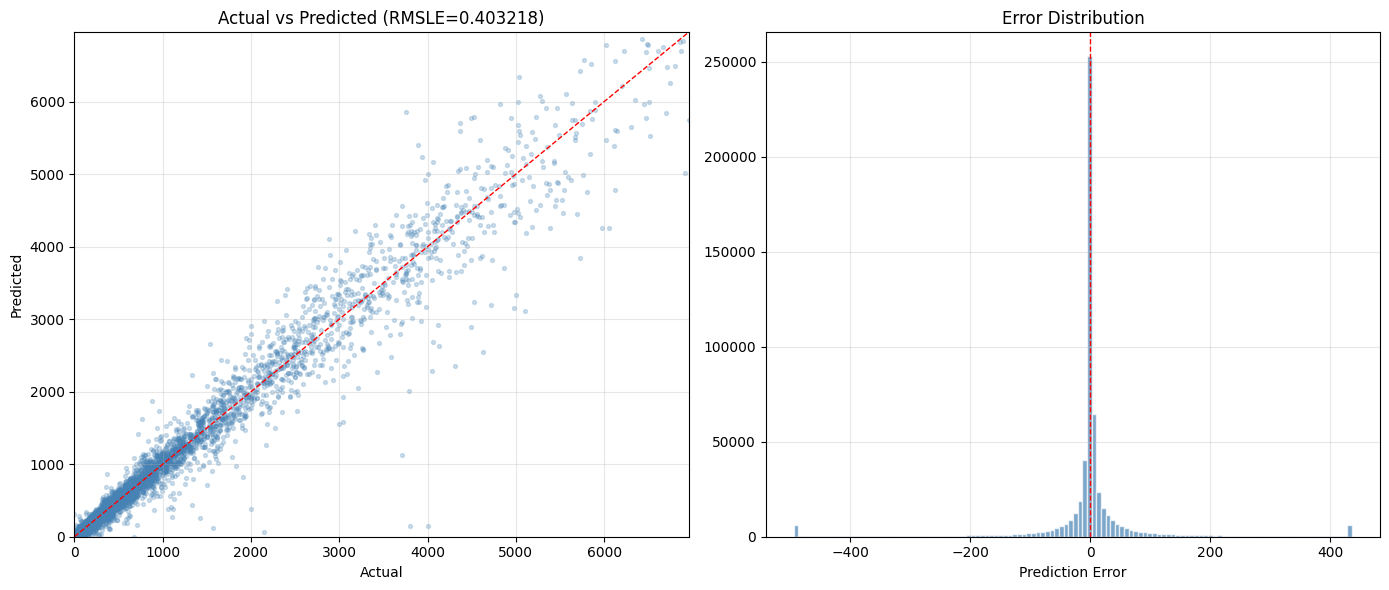

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Giả sử bạn đã có y_val, y_pred_lgb và rmse_lgb
val_pred = pd.DataFrame({
    'y_true_log': y_val,
    'y_pred_log': y_pred_lgb
})
val_pred['y_true'] = np.expm1(val_pred['y_true_log'])
val_pred['y_pred'] = np.maximum(np.expm1(val_pred['y_pred_log']), 0)
val_pred['error'] = val_pred['y_pred'] - val_pred['y_true']

# Giới hạn phạm vi để tránh outlier làm méo hình
val_pred = val_pred[
    (val_pred['y_true'] <= val_pred['y_true'].quantile(0.99)) &
    (val_pred['y_pred'] <= val_pred['y_pred'].quantile(0.99))
]

# Lấy mẫu ngẫu nhiên vừa đủ để nhìn thoáng
sample_idx = np.random.choice(len(val_pred), min(15000, len(val_pred)), replace=False)
sample = val_pred.iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Biểu đồ 1: Actual vs Predicted ---
max_val = max(sample['y_true'].max(), sample['y_pred'].max())
axes[0].scatter(sample['y_true'], sample['y_pred'], alpha=0.25, s=8, c='steelblue')
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted (RMSLE={rmse_lgb:.6f})') # Sử dụng rmse_lgb
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].grid(alpha=0.3)

# --- Biểu đồ 2: Error Distribution ---
errors = val_pred['error'].clip(val_pred['error'].quantile(0.01),
                                val_pred['error'].quantile(0.99))
axes[1].hist(errors, bins=120, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Error')
axes[1].set_title('Error Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_evaluation_linear.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Chuẩn bị X_test với cùng các feature đã dùng cho huấn luyện
# Đảm bảo các cột trong features_for_model đều có trong df_test_clean
# và loại bỏ các cột không cần thiết như 'sales_log', 'date', 'description'

# Xác định các cột cần loại trừ khỏi df_test_clean trước khi tạo X_test
# Cột 'id' sẽ được giữ lại để tạo file submission, sau đó thêm vào file submission.
# Sử dụng 'd4' thay vì 'test' vì 'test' đã bị xóa để tối ưu bộ nhớ.
submission_df_ids = d4['id'] # Lấy 'id' từ dataframe `d4` gốc

# df_test_clean hiện tại đã có tất cả các feature cần thiết, chúng ta chỉ cần chọn ra các feature_for_model
X_test = df_test_clean[features_for_model].copy()

# Dự đoán trên X_test
y_pred_test_log = lgb_model.predict(X_test)

# Chuyển đổi ngược từ log1p về sales thực tế
y_pred_test = np.expm1(y_pred_test_log)

# Đảm bảo không có giá trị sales âm
y_pred_test[y_pred_test < 0] = 0

# Tạo DataFrame submission
submission_df = pd.DataFrame({
    'id': d4['id'], # Sử dụng id từ dataframe `d4` gốc
    'sales': y_pred_test
})

# Lưu file submission
submission_df.to_csv('Final_submission.csv', index=False)

print("✅ Đã tạo file Final_submission.csv thành công!")
print(submission_df.head())

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
✅ Đã tạo file submission.csv thành công!
        id      sales
0  3000888  13.980788
1  3000889  14.738445
2  3000890   9.648088
3  3000891   8.458580
4  3000892   5.774763


Các feature quan trọng nhất (Top 20):


,Feature,Importance
11,transactions,6467
42,rolling_7_day_mean_sales_log,6209
37,lag_1_sales_log,5359
15,dayofweek,4832
56,sf_std_sales,4735
38,lag_7_sales_log,4206
14,day,4171
55,sf_mean_sales,4134
18,dayofyear,4099
53,family_mean_sales,3624


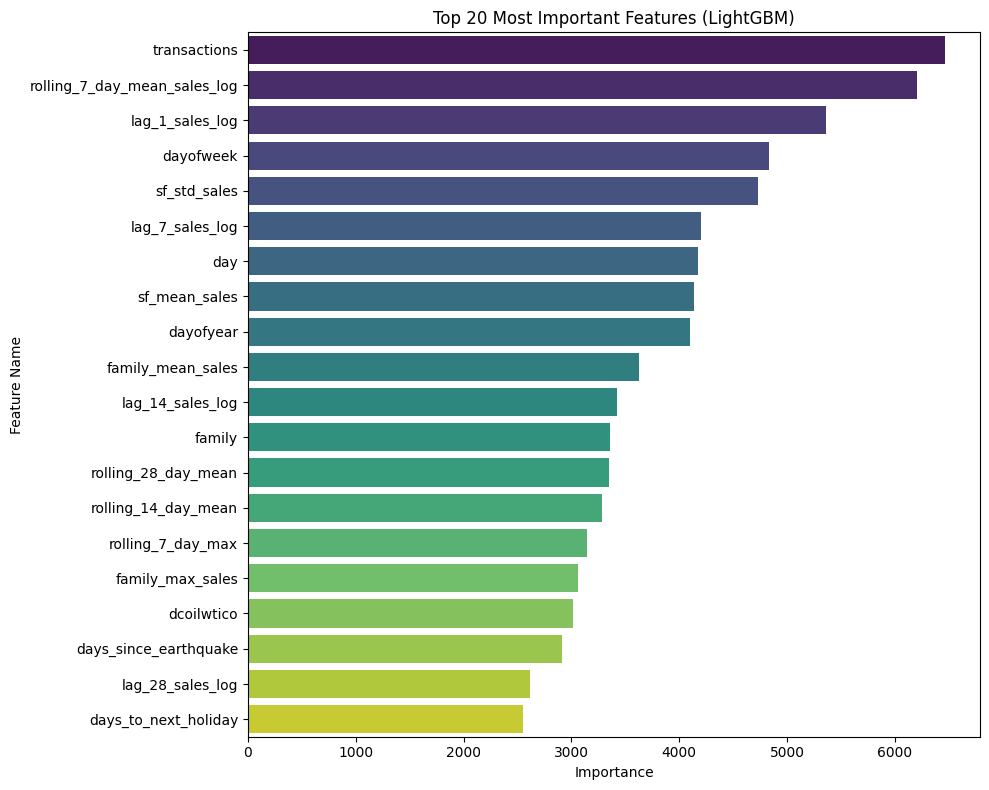

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy feature importances từ mô hình
feature_importances = lgb_model.feature_importances_

# Tạo DataFrame để dễ dàng xem và sắp xếp
importance_df = pd.DataFrame({
    'Feature': features_for_model,
    'Importance': feature_importances
})

# Sắp xếp các feature theo mức độ quan trọng giảm dần
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Các feature quan trọng nhất (Top 20):")
display(importance_df.head(20))

# Vẽ biểu đồ các feature quan trọng nhất
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Features (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [47]:
# ================================================================
# SO SÁNH KẾT QUẢ CÁC MODEL
# ================================================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Tính RMSLE cho từng model ─────────────────────────────────
def rmsle(y_true, y_pred):
    """Root Mean Squared Log Error — metric chính của Kaggle competition này"""
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# Quy đổi y_val và predictions về sales thực tế
y_val_real      = np.expm1(y_val.values)
y_pred_baseline = np.expm1(X_val['lag_1_sales_log'].values)
y_pred_lgb_real = np.expm1(y_pred_lgb)

# ── Tạo bảng so sánh ──────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Baseline (lag_1)', 'LightGBM'],
    'MAE'  : [
        mean_absolute_error(y_val, X_val['lag_1_sales_log'].values),
        mae_lgb
    ],
    'RMSE' : [
        np.sqrt(mean_squared_error(y_val, X_val['lag_1_sales_log'].values)),
        rmse_lgb
    ],
    'RMSLE': [
        rmsle(y_val_real, y_pred_baseline),
        rmsle(y_val_real, y_pred_lgb_real)
    ],
    'R²'   : [
        r2_score(y_val, X_val['lag_1_sales_log'].values),
        r2_lgb
    ]
}).round(4)

print("=" * 60)
print("         BẢNG SO SÁNH CÁC MÔ HÌNH")
print("=" * 60)
display(results)

# ── Tìm model tốt nhất và tính % cải thiện ───────────────────
best_idx      = results['RMSLE'].idxmin()
best_model    = results.loc[best_idx, 'Model']
best_rmsle    = results.loc[best_idx, 'RMSLE']
baseline_rmsle= results.loc[0, 'RMSLE']

improvement_lgb = (1 - results.loc[1,'RMSLE'] / baseline_rmsle) * 100

print(f"\n=== Final Results ===")
print(f"Best Baseline : Baseline (lag_1) — RMSLE={baseline_rmsle:.6f}")
print(f"LightGBM      : RMSLE={results.loc[1,'RMSLE']:.6f} — Cải thiện {improvement_lgb:.1f}% so với Baseline")
print(f"\n→ Model tốt nhất: {best_model} (RMSLE={best_rmsle:.6f})")


         BẢNG SO SÁNH CÁC MÔ HÌNH


,Model,MAE,RMSE,RMSLE,R²
0,Baseline (lag_1),0.4061,0.6751,0.6751,0.9313
1,LightGBM,0.2639,0.4032,0.4023,0.9755



=== Final Results ===
Best Baseline : Baseline (lag_1) — RMSLE=0.675100
LightGBM      : RMSLE=0.402300 — Cải thiện 40.4% so với Baseline

→ Model tốt nhất: LightGBM (RMSLE=0.402300)

Submission saved to Final_submission.csv


In [52]:
# Lấy các tên family gốc từ DataFrame d3
original_families = sorted(d3['family'].unique())

# Tạo mapping từ số đã encode sang tên gốc
family_decoder = {i: name for i, name in enumerate(original_families)}

# Áp dụng mapping vào cột 'family' trong family_error
family_error['family_name'] = family_error.index.map(family_decoder)

# Hiển thị lại Top 10 Families by MAE với tên gốc
print('Top 10 Families by MAE (với tên mặt hàng):')
display(family_error.head(10).set_index('family_name'))

Top 10 Families by MAE (với tên mặt hàng):


,RMSLE,MAE,count
family_name,,,
GROCERY I,0.169019,359.933565,14799
BEVERAGES,0.189420,323.754045,16053
PRODUCE,0.276906,212.542565,16271
CLEANING,0.219394,170.958756,17972
DAIRY,0.171296,95.158015,17981
BREAD/BAKERY,0.184057,59.342741,17982
POULTRY,0.239755,56.140227,17649
MEATS,0.241073,54.476712,17647
PERSONAL CARE,0.232897,51.177010,17649
